## Phase 4: Statistical EDA
### Part 1: Univariate Analysis

In [1]:
import pandas as pd
import seaborn as sns

In [2]:
df_filtered = pd.read_pickle("../data/cleaned_data.pkl")
df_filtered.head()

,id,title,company_name,category_label,category_tag,country,location_display,location_area,latitude,longitude,contract_type,contract_time,salary_min,salary_max,salary_mid,salary_is_predicted,created_dt,created_date,redirect_url,adref
0,5410474609,Mechanical Pipefitter,Dodd Group,Trade & Construction Jobs,trade-construction-jobs,United Kingdom,"King's Lynn, Norfolk",UK > Eastern England > Norfolk > King's Lynn,52.751999,0.395357,permanent,full_time,40518.74,40518.74,40518.74,1,2025-09-22 09:28:13+00:00,2025-09-22,https://www.adzuna.co.uk/jobs/details/54104746...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQxMDQ3NDYwOSIsI...
1,5381519011,International Trade Policy Editor [Startup Pol...,Applio Ventures,Graduate Jobs,graduate-jobs,United Kingdom,"London, UK",UK > London,NaN,NaN,permanent,full_time,64000.00,64000.00,64000.00,0,2025-09-03 21:20:59+00:00,2025-09-03,https://www.adzuna.co.uk/jobs/details/53815190...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTM4MTUxOTAxMSIsI...
3,5403097985,Early Years BABY Room Leader,Jesters Childcare Essex,Teaching Jobs,teaching-jobs,United Kingdom,UK,UK,NaN,NaN,permanent,full_time,26707.00,29494.00,28100.50,0,2025-09-17 15:00:12+00:00,2025-09-17,https://www.adzuna.co.uk/jobs/details/54030979...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQwMzA5Nzk4NSIsI...
5,5404665589,Computer Systems Validation specialist,North Star Consulting UK,Scientific & QA Jobs,scientific-qa-jobs,United Kingdom,"Newcastle Upon Tyne, Tyne & Wear",UK > North East England > Tyne & Wear > Newcas...,NaN,NaN,permanent,full_time,65000.00,65000.00,65000.00,0,2025-09-18 10:29:32+00:00,2025-09-18,https://www.adzuna.co.uk/jobs/details/54046655...,eyJhbGciOiJIUzI1NiJ9.eyJzIjoiRWtwZjc5cWI4QkdZM...
6,5404864465,Full Stack Software Engineer,Marshall Wolfe Ltd,IT Jobs,it-jobs,United Kingdom,UK,UK,NaN,NaN,permanent,full_time,0.00,60000.00,30000.00,0,2025-09-18 14:32:46+00:00,2025-09-18,https://www.adzuna.co.uk/jobs/details/54048644...,eyJhbGciOiJIUzI1NiJ9.eyJpIjoiNTQwNDg2NDQ2NSIsI...


In [3]:
# View relevant statistics for salary categories
print(df_filtered.nunique())
print(df_filtered[['salary_min', 'salary_max', 'salary_mid']].describe())

id                     1345
title                  1063
company_name            624
category_label           67
category_tag             30
country                   8
location_display        964
location_area           964
latitude                963
longitude               963
contract_type             2
contract_time             2
salary_min              795
salary_max              807
salary_mid              916
salary_is_predicted       2
created_dt             1096
created_date            211
redirect_url           1345
adref                  1346
dtype: int64
          salary_min     salary_max     salary_mid
count    1346.000000    1346.000000    1346.000000
mean    47527.442578   53017.268730   50272.355654
std     35305.787348   37694.082998   35959.681985
min         0.000000    1000.000000     601.000000
25%     26028.625000   30000.000000   28000.000000
50%     38425.450000   45020.925000   41791.315000
75%     59281.612500   65000.000000   61094.892500
max    384000.00000

Value Counts for each job description:

category_tag
healthcare-nursing-jobs          224
unknown                          221
teaching-jobs                    119
customer-services-jobs            92
logistics-warehouse-jobs          90
engineering-jobs                  77
trade-construction-jobs           59
it-jobs                           55
travel-jobs                       52
sales-jobs                        51
social-work-jobs                  50
hospitality-catering-jobs         40
manufacturing-jobs                34
accounting-finance-jobs           30
admin-jobs                        18
legal-jobs                        17
part-time-jobs                    16
retail-jobs                       16
maintenance-jobs                  14
pr-advertising-marketing-jobs     11
other-general-jobs                11
creative-design-jobs              10
domestic-help-cleaning-jobs       10
graduate-jobs                     10
consultancy-jobs                   5
hr-jobs               

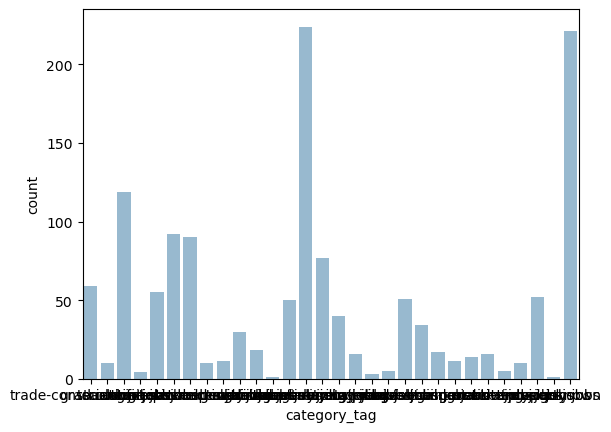

In [7]:
# Visualize the spread of job types
sns.countplot(data = df_filtered, x = 'category_tag', alpha = 0.5)
print(f'Value Counts for each job description:\n\n{df_filtered['category_tag'].value_counts()}')

Healthcare accounts for the vast majority of job types with teaching, customer service, logistics, and engineering jobs accounting for another majority
It will be important to compare salary levels across these job types and make sure to account for low frequency jobs and their salaries in any consideration.

Value Counts for each job description:

country
USA               499
United Kingdom    480
Netherlands       129
France             92
Spain              88
Italy              43
Switzerland         8
Germany             7
Name: count, dtype: int64


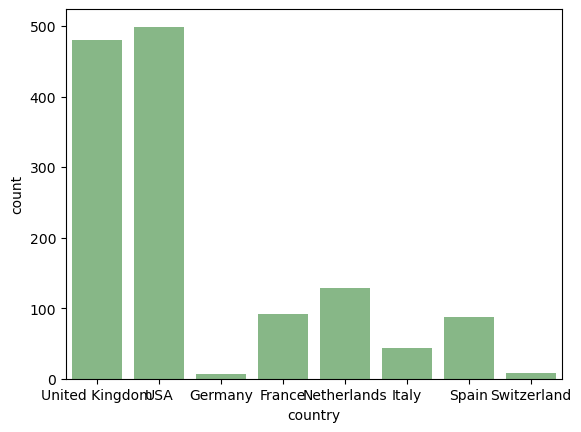

In [8]:
# Visualize the distribution of job locations
sns.countplot(data = df_filtered, x = 'country', color = 'Green', alpha = 0.5)
print(f'Value Counts for each job description:\n\n{df_filtered['country'].value_counts()}')

Univariate analysis was duplicated from the job description analysis for countries. The United States and United Kingdom represent the location where the majority of jobs are found. France Netherlands and Spain are also countries to consider in locating trends in the data.


### Part 2: Bivariate Analysis

Descending sort of average minimum salary by job:
                                       mean           std           var
category_tag                                                           
healthcare-nursing-jobs        81303.923080  46495.020812  2.161787e+09
accounting-finance-jobs        71100.483333  75967.892929  5.771121e+09
legal-jobs                     69754.387647  46301.875898  2.143864e+09
it-jobs                        64791.864000  32370.047556  1.047820e+09
travel-jobs                    61821.350192  15487.669114  2.398679e+08
scientific-qa-jobs             61565.325000  16135.025710  2.603391e+08
part-time-jobs                 60914.430625  42890.483824  1.839594e+09
property-jobs                  60000.000000           NaN           NaN
energy-oil-gas-jobs            53185.106667   2980.926359  8.885922e+06
sales-jobs                     52564.035098  26876.459066  7.223441e+08
trade-construction-jobs        50801.107119  25153.894424  6.327184e+08
engineering-jo

<Axes: xlabel='salary_min', ylabel='category_tag'>

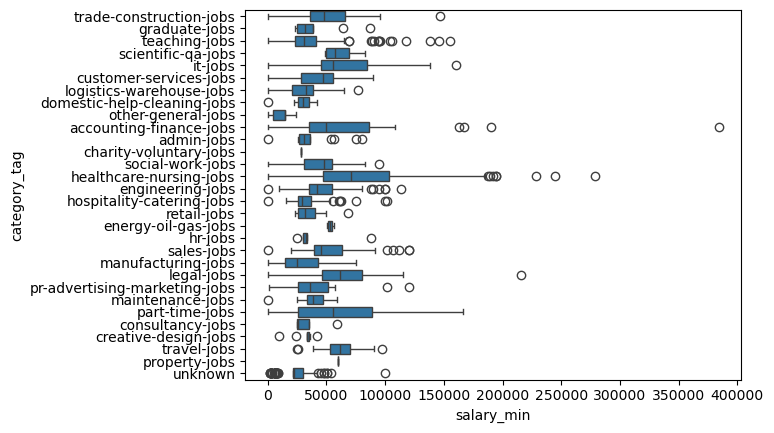

In [9]:
# Group salary by job type
df_job_type = df_filtered.groupby('category_tag')[['salary_min', 'salary_max', 'salary_mid']].agg(['mean', 'std', 'var'])

# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average minimum salary by job:")
print(df_job_type['salary_min'].sort_values(by = 'mean', ascending = False))

sns.boxplot(data = df_filtered, x = 'salary_min', y = 'category_tag')

In [ ]:
print("Descending sort of average maximum salary by job:")
print(df_job_type['salary_max'].sort_values(by = 'mean', ascending = False))

sns.boxplot(data = df_filtered, x = 'salary_max', y = 'category_tag')

In [ ]:
# Repeat for location
df_location = df_filtered.groupby('country')[['salary_min', 'salary_max', 'salary_mid']].agg(['mean', 'std', 'var'])

# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average minimum salary by country:")
print(df_location['salary_min'].sort_values(by = 'mean', ascending = False))

sns.boxplot(data = df_filtered, x = 'salary_min', y = 'country')

In [ ]:
# Identify job types with the highest and lowest minimum salary and maximum salary
print("Descending sort of average maximum salary by country:")
print(df_location['salary_min'].sort_values(by = 'mean', ascending = False))

sns.boxplot(data = df_filtered, x = 'salary_max', y = 'country')

In [ ]:
jobs_by_country = pd.crosstab(index = df_filtered['category_tag'], columns = df_filtered['country'])

german_jobs = jobs_by_country[(jobs_by_country['Germany'] != 0)]
german_jobs

### Part 3: Multivariate Analysis

In [ ]:
sns.pairplot(df_filtered, hue = 'country')

In [ ]:
us_uk = df_filtered[(df_filtered['country'] == 'United Kingdom') | (df_filtered['country'] == 'USA')]
us_uk


sns.lineplot(data = us_uk, x = 'category_tag', y = 'salary_mid', hue = 'country')